In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.float_format', '{:.2f}'.format)

## Создадим фейковый датасет

In [3]:
# Количество событий
n = 100_000

# случайные даты
dates = pd.to_datetime(np.random.choice(pd.date_range('2026-01-01', '2026-12-31'), size = n))

# случайные часы, минуты, секунды
hours = np.random.randint(0, 24, n)
minutes = np.random.randint(0, 60, n)
seconds = np.random.randint(0, 60, n)

df = pd.DataFrame({'datetime': dates})

df['datetime'] = (df['datetime'] + pd.to_timedelta(hours, unit = 'h')
                                 + pd.to_timedelta(minutes, unit = 'm')
                                 + pd.to_timedelta(seconds, unit = 's'))

df.head()

,datetime
0,2026-06-06 12:54:53
1,2026-05-26 08:59:02
2,2026-08-10 10:29:39
3,2026-12-25 12:06:51
4,2026-01-06 17:57:30


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 1 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   datetime  100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 781.4 KB


## Чек гостя
От 300 до 50000 рублей, распределение лог-нормальное, условно больше мелких чеков и меньше больших

In [5]:
rng = np.random.default_rng()
bills = rng.lognormal(mean = 8.2, sigma = 1.0, size = n)

bills = np.clip(bills, 300, 50000)
bills = pd.Series(np.round(bills, 2), name = 'bills')

## Чаевые
Каждый третий гость оставил чаевые от 3% до 20%

In [6]:
has_tip = rng.random(n) < 0.3
has_tip_series = pd.Series(has_tip, name = 'has_tip')
tip_rate = rng.uniform(0.03, 0.20, size = n)

tips = np.where(has_tip, bills * tip_rate, 0)
tips = pd.Series(np.round(tips, 2), name = 'tips')

## Склеим датафрейм

In [7]:
full_data = pd.concat([df, bills, tips, has_tip_series], axis = 1)
full_data = full_data.sort_values(by = 'datetime')
full_data = full_data.sample(frac = 1, replace = False).reset_index(drop = True)
full_data.head()

,datetime,bills,tips,has_tip
0,2026-10-06 00:58:21,10981.80,0.00,False
1,2026-09-06 11:00:34,2378.01,0.00,False
2,2026-11-16 14:51:26,1074.37,0.00,False
3,2026-09-14 22:19:16,4424.68,384.25,True
4,2026-11-21 02:38:41,5027.96,0.00,False


## Обогащаем признаками

In [8]:
full_data['share'] = full_data['tips'] / full_data['bills'] * 100
full_data['bill_volume'] = pd.qcut(full_data['bills'], q = 5)

In [9]:
full_data['month'] = full_data['datetime'].dt.month
full_data['weekday'] = full_data['datetime'].dt.day_name()
full_data['hour'] = full_data['datetime'].dt.hour


def get_daypart(hour: int) -> str:
    if 0 <= hour < 6:
        return 'Ночь'
    elif 6 <= hour < 12:
        return 'Утро'
    elif 12 <= hour < 18:
        return 'Обед'
    else:
        return 'Вечер'

full_data['daypart'] = full_data['hour'].apply(get_daypart)

In [10]:
full_data.head()

,datetime,bills,tips,has_tip,share,bill_volume,month,weekday,hour,daypart
0,2026-10-06 00:58:21,10981.80,0.00,False,0.00,"(8460.58, 50000.0]",10,Tuesday,0,Ночь
1,2026-09-06 11:00:34,2378.01,0.00,False,0.00,"(1580.796, 2859.548]",9,Sunday,11,Утро
2,2026-11-16 14:51:26,1074.37,0.00,False,0.00,"(299.999, 1580.796]",11,Monday,14,Обед
3,2026-09-14 22:19:16,4424.68,384.25,True,8.68,"(2859.548, 4721.674]",9,Monday,22,Вечер
4,2026-11-21 02:38:41,5027.96,0.00,False,0.00,"(4721.674, 8460.58]",11,Saturday,2,Ночь


In [11]:
full_data.describe()

,datetime,bills,tips,share,month,hour
count,100000,100000.00,100000.00,100000.00,100000.00,100000.00
mean,2026-07-02 09:56:18.478210048,5926.89,206.24,3.46,6.52,11.47
min,2026-01-01 00:01:18,300.00,0.00,0.00,1.00,0.00
25%,2026-04-01 22:30:34.249999872,1866.20,0.00,0.00,4.00,5.00
50%,2026-07-02 03:37:01.500000,3674.86,0.00,0.00,7.00,12.00
75%,2026-10-02 04:41:47,7170.26,128.84,5.88,10.00,17.00
max,2026-12-31 23:49:14,50000.00,9993.63,20.00,12.00,23.00
std,NaN,6921.87,600.18,5.92,3.45,6.92


## Воспроизводим таблицы и графики

In [12]:
full_data.groupby('bill_volume', observed = True)['share'].mean().reset_index()

,bill_volume,share
0,"(299.999, 1580.796]",3.50
1,"(1580.796, 2859.548]",3.41
2,"(2859.548, 4721.674]",3.57
3,"(4721.674, 8460.58]",3.39
4,"(8460.58, 50000.0]",3.45


In [13]:
full_data.groupby('daypart', observed = True)['tips'].mean().reset_index()

,daypart,tips
0,Вечер,206.56
1,Ночь,201.68
2,Обед,206.20
3,Утро,210.58


In [14]:
heatmap = pd.pivot_table(full_data, 
                         values = 'share',
                         index = 'weekday',
                         columns = 'hour',
                         aggfunc = 'mean')

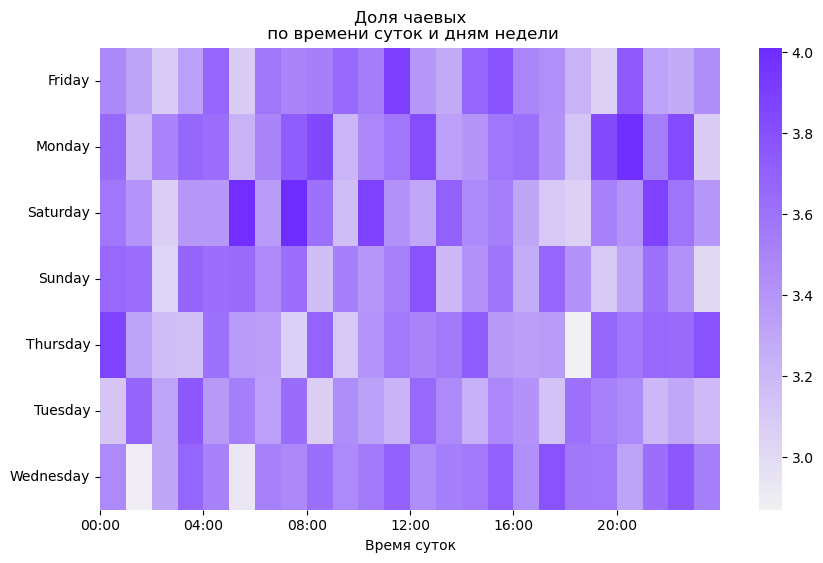

In [15]:
plt.figure(figsize=(10, 6))

sns.heatmap(heatmap, cmap = sns.light_palette("#6f2cff", as_cmap = True),
            linewidths = 0, cbar = True)

plt.xlabel('Время суток')
plt.ylabel('')
plt.title('Доля чаевых\n по времени суток и дням недели')

# подписи часов
plt.xticks(ticks = [0, 4, 8, 12, 16, 20], labels = ['00:00', '04:00', '08:00', '12:00', '16:00', '20:00'])

plt.show()

In [16]:
weekday_order = ['Monday', 'Thursday', 'Wednesday', 'Tuesday', 'Friday', 'Saturday', 'Sunday']
daypart_order = ['Ночь', 'Утро', 'Обед', 'Вечер']

heatmap = pd.pivot_table(full_data, 
                         values = 'tips',
                         index = 'weekday',
                         columns = 'daypart',
                         aggfunc = 'mean').reindex(index = weekday_order, columns = daypart_order)

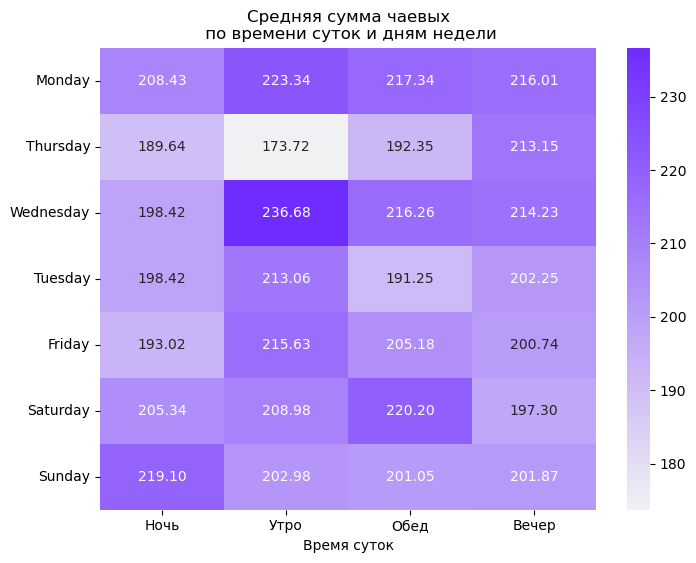

In [17]:
annot = heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(heatmap, cmap = sns.light_palette("#6f2cff", as_cmap = True),
            linewidths = 0, cbar = True, square = False, annot = annot,  fmt='.2f')

plt.xlabel('Время суток')
plt.ylabel('')
plt.title('Средняя сумма чаевых\n по времени суток и дням недели')

plt.show()

In [18]:
visitors_load = full_data.groupby('month')['bills'].count()
has_tip_totals = full_data.groupby('month')['has_tip'].sum()
avg_bill = full_data.groupby('month')['bills'].mean()
avg_tip_share = full_data.groupby('month')['share'].mean()

In [19]:
full_data_by_month = pd.concat([visitors_load, has_tip_totals, avg_bill, avg_tip_share], axis = 1).reset_index()
full_data_by_month.columns = ['month', 'bills_count', 'tips_count',	'average_bill', 'avg_tip_share']

full_data_by_month['bills_with_tips_share'] = full_data_by_month['tips_count'] / full_data_by_month['bills_count'] * 100

In [20]:
month_map = {1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр',
             5: 'Май', 6: 'Июн', 7: 'Июл', 8: 'Авг',
             9: 'Сен', 10: 'Окт', 11: 'Ноя', 12: 'Дек'}

full_data_by_month['month_ru'] = full_data_by_month['month'].map(month_map)

In [21]:
full_data_by_month.head()

,month,bills_count,tips_count,average_bill,avg_tip_share,bills_with_tips_share,month_ru
0,1,8587,2620,5934.60,3.50,30.51,Янв
1,2,7641,2202,5787.90,3.32,28.82,Фев
2,3,8519,2530,6082.67,3.40,29.70,Мар
3,4,8185,2463,5927.68,3.47,30.09,Апр
4,5,8604,2651,6014.18,3.52,30.81,Май


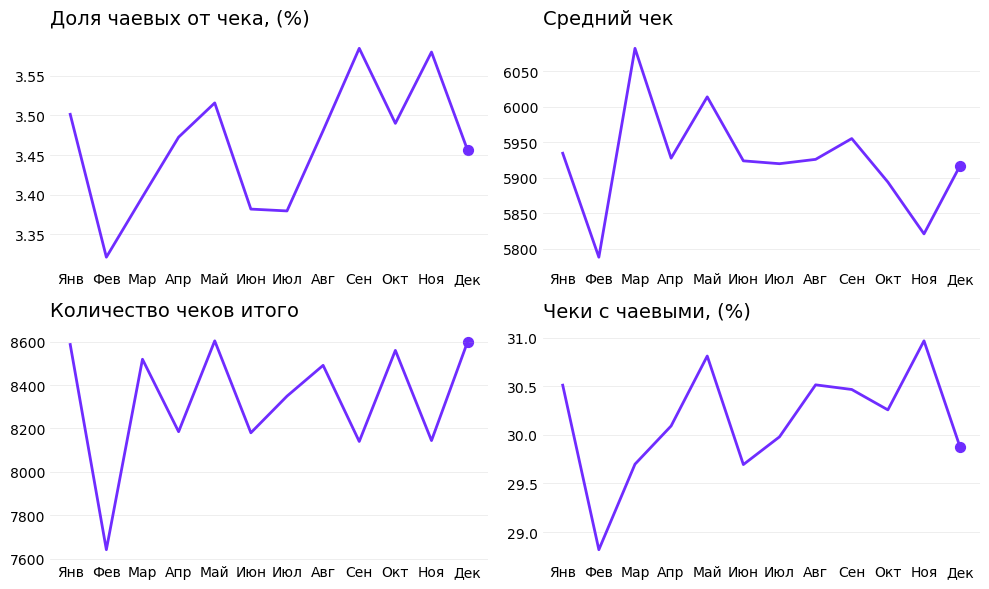

In [22]:
def plot_metrics(df, x_col = 'month_ru'):
    metrics = [('avg_tip_share', 'Доля чаевых от чека, (%)', '%'),
               ('average_bill', 'Средний чек', 'руб.'),
               ('bills_count', 'Количество чеков итого', ''),
               ('bills_with_tips_share', 'Чеки с чаевыми, (%)', '')]
    
    # стиль
    purple = '#6f2cff'
    
    fig, axes = plt.subplots(2, 2, figsize = (10, 6))
    axes = axes.flatten()
    
    for i, (col, title, ylabel) in enumerate(metrics):
        ax = axes[i]
        
        # линия
        ax.plot(df[x_col], df[col], linewidth = 2)
        ax.scatter(df[x_col].iloc[-1], df[col].iloc[-1], s = 50)  # последняя точка
        
        # заголовок
        ax.set_title(title, loc = 'left', fontsize = 14, pad = 10)
        
        # минимализм
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        
        # сетка только по Y
        ax.grid(axis = 'y', linestyle = '-', linewidth = 0.5, alpha = 0.3)
        ax.grid(axis = 'x', visible=False)
        
        # подписи
        ax.set_xlabel('')
        ax.set_ylabel('')
        
        # убираем лишние тики
        ax.tick_params(axis = 'both', which = 'both', length = 0)
        
    # применяем цвет после 
    for ax in axes:
        for line in ax.lines:
            line.set_color(purple)
        for collection in ax.collections:
            collection.set_color(purple)
    
    plt.tight_layout()
    plt.show()


plot_metrics(full_data_by_month)

По материалам исследования банка Точка:
https://allo.tochka.com/business-research/tips